# PREDICCIÓN DE VENTAS ALTADIS — 3 MESES Y 1 AÑO
### Google Colab — Prophet (v3 — gráfico limpio)

In [ ]:
# 1. Instalar librería
!pip install prophet -q

In [ ]:
import pandas as pd
import numpy as np
from prophet import Prophet
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from google.colab import files

In [ ]:
# 2. Subir el fichero
uploaded = files.upload()

SALES = pd.read_csv('SalesDay (1).csv', sep=';', encoding='utf-8-sig',
                    dtype={'Sales_DAY': str, 'Sales_Uds': float})
SALES.columns = SALES.columns.str.strip()
SALES['Sales_DAY'] = pd.to_datetime(SALES['Sales_DAY'], format='%Y%m%d')

print(f"Registros cargados: {len(SALES):,}")
print(f"Período: {SALES['Sales_DAY'].min().date()} → {SALES['Sales_DAY'].max().date()}")

Saving SalesDay (1).csv to SalesDay (1).csv
Registros cargados: 2,878,182
Período: 2015-03-09 → 2015-10-04


In [ ]:
print(SALES.head())
print(f"Min ventas día: {SALES['Sales_Uds'].min()}")
print(f"Max ventas día: {SALES['Sales_Uds'].max()}")
print(f"Media ventas día: {SALES['Sales_Uds'].mean():.0f}")

   Sales_DAY Affiliated_Code Product_Code  Sales_Uds
0 2015-08-26         WjxnAAD      Brit627        1.0
1 2015-08-26         WjkSAAT      Brit627        1.0
2 2015-08-28         WU41AAH      Brit700        7.0
3 2015-08-27         XCvxAAH      Brit700        5.0
4 2015-08-27         XCcjAAH      Brit700        1.0
Min ventas día: -57.0
Max ventas día: 351.0
Media ventas día: 2


In [ ]:
# 3. Agregar ventas por semana (reduce ruido y picos)
ventas_dia = (SALES
              .groupby('Sales_DAY')['Sales_Uds']
              .sum()
              .reset_index()
              .rename(columns={'Sales_DAY': 'ds', 'Sales_Uds': 'y'}))
# Eliminar último día si está incompleto
ultimo_dia = ventas_dia['ds'].max()
ventas_dia = ventas_dia[ventas_dia['ds'] < ultimo_dia].copy()
print(f"Último día eliminado: {ultimo_dia.date()} (dato incompleto)")

# Eliminar outliers (valores > percentil 99)
p01 = ventas_dia['y'].quantile(0.01)
p99 = ventas_dia['y'].quantile(0.99)
outliers = ventas_dia[(ventas_dia['y'] > p99) | (ventas_dia['y'] < p01)]
print(f"Outliers eliminados: {len(outliers)} días")
print(f"  → Por exceso  (>{p99:.0f} uds): {len(ventas_dia[ventas_dia['y'] > p99])}")
print(f"  → Por defecto (<{p01:.0f} uds): {len(ventas_dia[ventas_dia['y'] < p01])}")

ventas_dia = ventas_dia[
    (ventas_dia['y'] >= p01) &
    (ventas_dia['y'] <= p99)
].copy()
# Agregar a semana para suavizar
ventas_semana = (ventas_dia
                 .set_index('ds')
                 .resample('W')['y']
                 .sum()
                 .reset_index())

print(f"Semanas para el modelo: {len(ventas_semana)}")
print(f"Venta media semanal: {ventas_semana['y'].mean():.0f} uds")

Último día eliminado: 2015-10-04 (dato incompleto)
Outliers eliminados: 6 días
  → Por exceso  (>41494 uds): 3
  → Por defecto (<3976 uds): 3
Semanas para el modelo: 30
Venta media semanal: 181200 uds


In [ ]:
# 4. Ajustar el modelo (datos semanales, sin estacionalidad semanal)
modelo = Prophet(
    weekly_seasonality=False,
    daily_seasonality=False,
    interval_width=0.80,          # banda de confianza más estrecha
    changepoint_prior_scale=0.01,  # tendencia más suave
    seasonality_mode='additive'
)
# Añadir estacionalidad mensual manualmente (más apropiada para 30 semanas)
modelo.add_seasonality(name='monthly', period=30.5, fourier_order=3)
modelo.fit(ventas_semana)
print("Modelo entrenado ✓")

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 23.


Modelo entrenado ✓


In [ ]:
# 5. Función para graficar de forma limpia
def grafico_limpio(pred, titulo, nombre_fichero, datos_reales):
    fig, ax = plt.subplots(figsize=(12, 5))

    # Separar histórico y futuro
    corte = datos_reales['ds'].max()
    hist  = pred[pred['ds'] <= corte]
    fut   = pred[pred['ds'] >  corte]

    # Banda de incertidumbre — solo futuro
    ax.fill_between(fut['ds'], fut['yhat_lower'], fut['yhat_upper'],
                    color='steelblue', alpha=0.15, label='Intervalo 80%')

    # Línea de tendencia histórica
    ax.plot(hist['ds'], hist['yhat'], color='steelblue', linewidth=1.5,
            label='Tendencia histórica')

    # Línea de predicción futura
    ax.plot(fut['ds'], fut['yhat'], color='tomato', linewidth=2,
            linestyle='--', label='Predicción')

    # Datos reales (puntos pequeños y transparentes)
    ax.scatter(datos_reales['ds'], datos_reales['y'],
               color='navy', s=10, alpha=0.3, label='Ventas reales')

    # Línea vertical de separación
    ax.axvline(corte, color='gray', linestyle=':', linewidth=1)
    ax.text(corte, ax.get_ylim()[1]*0.95, '  Hoy', color='gray', fontsize=9)

    ax.set_title(titulo, fontsize=14, fontweight='bold')
    ax.set_xlabel('Fecha')
    ax.set_ylabel('Unidades (semanales)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.xticks(rotation=30)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(nombre_fichero, dpi=150)
    plt.show()
    print(f"Guardado: {nombre_fichero}")

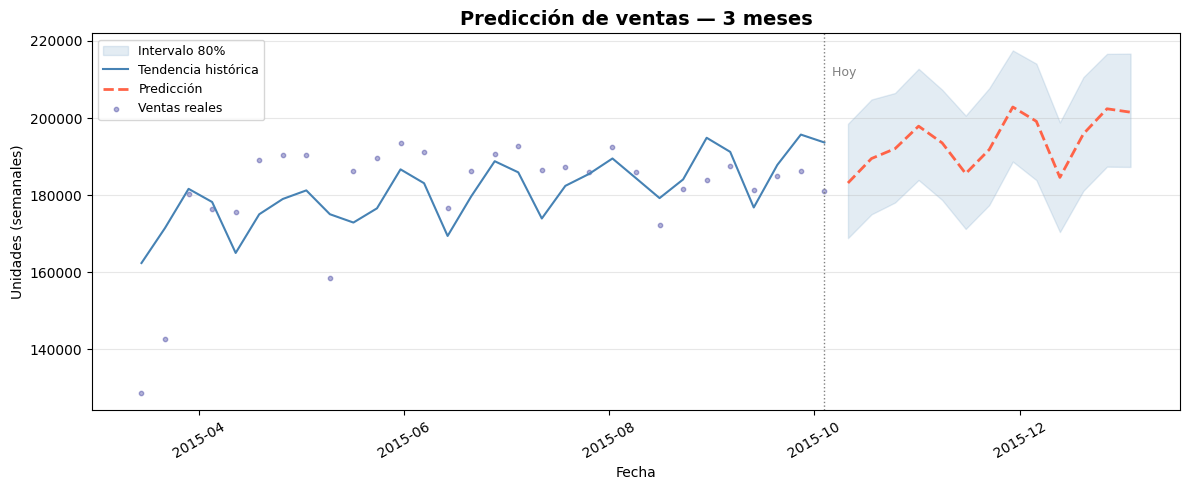

Guardado: prediccion_3meses.png


In [ ]:
# 6. Predicción a 3 meses (~13 semanas)
futuro_3m = modelo.make_future_dataframe(periods=13, freq='W')
pred_3m   = modelo.predict(futuro_3m)
grafico_limpio(pred_3m, 'Predicción de ventas — 3 meses',
               'prediccion_3meses.png', ventas_semana)

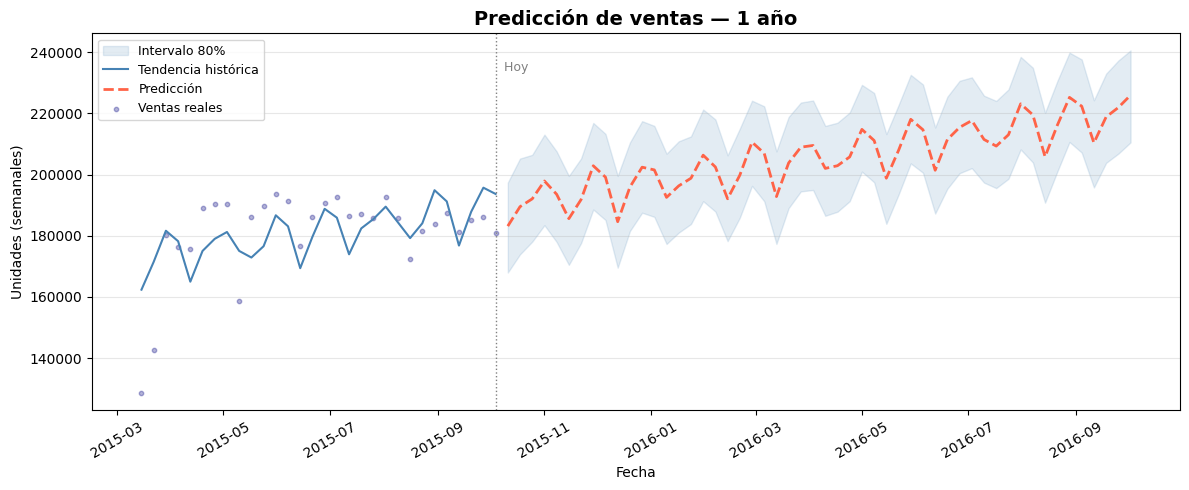

Guardado: prediccion_1anio.png


In [ ]:
# 7. Predicción a 1 año (~52 semanas)
futuro_1a = modelo.make_future_dataframe(periods=52, freq='W')
pred_1a   = modelo.predict(futuro_1a)
grafico_limpio(pred_1a, 'Predicción de ventas — 1 año',
               'prediccion_1anio.png', ventas_semana)

In [ ]:
# 8. Resumen mensual
pred_futuro = pred_1a[pred_1a['ds'] > ventas_semana['ds'].max()].copy()
pred_futuro['mes'] = pred_futuro['ds'].dt.to_period('M')
resumen = pred_futuro.groupby('mes')['yhat'].sum().round(0)
print("\nVentas previstas por mes (uds semanales acumuladas):")
print(resumen.to_string())


Ventas previstas por mes (uds semanales acumuladas):
mes
2015-10     564701.0
2015-11     971715.0
2015-12     782046.0
2016-01     995485.0
2016-02     804927.0
2016-03     812476.0
2016-04     820164.0
2016-05    1050611.0
2016-06     842906.0
2016-07    1074498.0
2016-08     866614.0
2016-09     873401.0
2016-10     225924.0
Freq: M


In [ ]:
# Para exportar resumen mensual
# Exportar resumen mensual sin meses incompletos
resumen_df = resumen.reset_index()
resumen_df.columns = ['Mes', 'Prediccion_Mensual']
resumen_df['Mes'] = resumen_df['Mes'].astype(str)
resumen_df['Prediccion_Mensual'] = resumen_df['Prediccion_Mensual'].astype(int)

# Eliminar meses incompletos
resumen_df = resumen_df[~resumen_df['Mes'].isin(['2015-10', '2016-10'])]

resumen_df.to_csv('resumen_mensual.csv', index=False, sep=';')
files.download('resumen_mensual.csv')
print(resumen_df.to_string())

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

        Mes  Prediccion_Mensual
1   2015-11              971715
2   2015-12              782046
3   2016-01              995485
4   2016-02              804927
5   2016-03              812476
6   2016-04              820164
7   2016-05             1050611
8   2016-06              842906
9   2016-07             1074498
10  2016-08              866614
11  2016-09              873401


In [ ]:
# 9. Exportar CSV
# 9. Exportar CSV combinado con horizonte
pred_1a_export = pred_1a[['ds','yhat','yhat_lower','yhat_upper']].copy()
pred_1a_export['horizonte'] = '1_anio'

pred_3m_export = pred_3m[['ds','yhat','yhat_lower','yhat_upper']].copy()
pred_3m_export['horizonte'] = '3_meses'

prediccion_final = pd.concat([pred_1a_export, pred_3m_export]).reset_index(drop=True)

prediccion_final.to_csv('prediccion_ventas.csv', index=False, sep=';')

print(f"Total filas exportadas: {len(prediccion_final)}")
print(f"  → 1 año:   {len(pred_1a_export)} filas")
print(f"  → 3 meses: {len(pred_3m_export)} filas")
print("Fichero guardado: prediccion_ventas.csv")

Total filas exportadas: 125
  → 1 año:   82 filas
  → 3 meses: 43 filas
Fichero guardado: prediccion_ventas.csv


In [ ]:
# Verificar predicciones antes de exportar
print(pred_1a[['ds','yhat','yhat_lower','yhat_upper']].tail(10))
print(f"\nPredicción media semanal: {pred_1a['yhat'].mean():.0f}")

           ds           yhat     yhat_lower     yhat_upper
72 2016-07-31  223099.043519  208204.139224  238440.049762
73 2016-08-07  219504.518380  203959.594306  234895.660270
74 2016-08-14  205819.584945  190801.069943  220219.206116
75 2016-08-21  216076.064284  200925.604269  230488.963223
76 2016-08-28  225213.403797  210637.684779  239829.336871
77 2016-09-04  222326.404308  207173.332427  237605.196733
78 2016-09-11  210353.285386  195766.669755  224268.294245
79 2016-09-18  218825.131273  203818.178165  232947.802596
80 2016-09-25  221896.648438  206823.494021  237244.270859
81 2016-10-02  225923.940618  210492.833228  240549.013039

Predicción media semanal: 196544


In [ ]:
prediccion_final.to_csv(
    'prediccion_ventas.csv',
    index=False,
    sep=';',
    float_format='%.2f'  # evita notación científica
)
files.download('prediccion_ventas.csv')
print("CSV exportado correctamente")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

CSV exportado correctamente


In [ ]:
pred_3m[pred_3m['ds'].dt.month == 1][['ds','yhat','yhat_lower','yhat_upper']]

,ds,yhat,yhat_lower,yhat_upper
42,2016-01-03,201512.533901,187307.208724,216712.487413
